
# EDA: Pin-Fin CHF — Water / FC-72 (`pinfin_chf_water_fc72.csv`)

Pool-boiling critical heat flux measurements on micro-pin-fin enhanced
surfaces, water and FC-72 dielectric fluid.

**Note on duplication**: `data/raw/external/CHF Dataset.csv` is a
byte-identical copy of `pinfin_chf_water_fc72.csv` (verified below). This
notebook treats them as a single dataset and analyzes only
`pinfin_chf_water_fc72.csv`.

## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/pinfin_chf_water_fc72")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SLUG = "pinfin_chf_water_fc72"
SLUG_TITLE = "Pin-Fin CHF (Water/FC-72)"

df = pd.read_csv(DATA_DIR / "pinfin_chf_water_fc72.csv", encoding="utf-8-sig")
dup = pd.read_csv(DATA_DIR / "CHF Dataset.csv", encoding="utf-8-sig")
print("CHF Dataset.csv is byte-identical to pinfin_chf_water_fc72.csv:", df.equals(dup))

NUMERIC_COLS = ["Subcooling(K)", "Width(um)", "Height(um)", "Spacing(um)", "Coverage",
                "Porosity", "MBL, Lateral (um)", "MBL, Total (um)", "Roughness Factor",
                "CHF(kW/m2)"]
CATEGORICAL_COLS = ["Fin Shape", "Fin Array", "Surface Material", "Fluid"]
TARGET_COL = "CHF(kW/m2)"

df.head()

CHF Dataset.csv is byte-identical to pinfin_chf_water_fc72.csv: True


,Fin Shape,Fin Array,Subcooling(K),Width(um),Height(um),Spacing(um),Coverage,Porosity,"MBL, Lateral (um)","MBL, Total (um)",Roughness Factor,Surface Material,Fluid,CHF(kW/m2),Source
0,NaN,NaN,0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,1.000,SiO2,Water,778.2,Chu et al. 2012\nhttps://doi.org/10.1063/1.472...
1,Circle,Square,0,10.0,10.0,15.0,1.0,0.874,69.577,23.274,1.503,SiO2,Water,1646.1,NaN
2,Circle,Square,0,10.0,20.0,15.0,1.0,0.874,69.577,34.881,2.005,SiO2,Water,1678.5,NaN
3,Circle,Square,0,5.0,20.0,10.0,1.0,0.913,52.296,30.472,2.396,SiO2,Water,1764.8,NaN
4,Circle,Square,0,10.0,20.0,10.0,1.0,0.804,40.930,25.009,2.571,SiO2,Water,1888.9,NaN


## 2. Data Quality

In [2]:
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing if len(missing) else "None")
print()
print("Duplicate rows:", df.duplicated().sum())

Shape: (175, 15)

Dtypes:
Fin Shape             object
Fin Array             object
Subcooling(K)          int64
Width(um)            float64
Height(um)           float64
Spacing(um)          float64
Coverage             float64
Porosity             float64
MBL, Lateral (um)    float64
MBL, Total (um)      float64
Roughness Factor     float64
Surface Material      object
Fluid                 object
CHF(kW/m2)           float64
Source                object
dtype: object

Missing values per column:
Source       159
Fin Shape     30
Fin Array     30
dtype: int64

Duplicate rows: 3


## 3. Descriptive Statistics

In [3]:
numeric_summary = df[NUMERIC_COLS].describe().T
numeric_summary.to_csv(OUT_DIR / "summary_stats.csv")
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Subcooling(K),175.0,14.217143,15.628913,0.0,0.000,3.00,25.0000,45.000
Width(um),175.0,165.615771,327.797699,0.0,10.000,30.00,50.0000,1000.000
Height(um),175.0,591.505554,1442.855257,0.0,18.500,60.00,200.0000,8000.000
Spacing(um),175.0,177.453943,393.834311,0.0,10.000,30.00,50.0000,2000.000
Coverage,175.0,0.779269,0.375053,0.0,0.700,1.00,1.0000,1.000
Porosity,175.0,0.615109,0.291766,0.0,0.636,0.75,0.7500,0.997
"MBL, Lateral (um)",175.0,585.754400,1408.001482,0.0,28.457,90.00,150.0000,8000.000
"MBL, Total (um)",175.0,353.063880,781.906829,0.0,22.883,60.00,90.3675,5120.000
Roughness Factor,175.0,3.627103,2.703876,1.0,1.887,3.00,5.0000,16.000
CHF(kW/m2),175.0,591.108571,455.197159,154.8,308.850,459.90,622.5000,2190.000


## 4. Categorical Value Counts

In [4]:
for col in CATEGORICAL_COLS:
    print(f"--- {col} (n_unique={df[col].nunique(dropna=True)}) ---")
    print(df[col].value_counts(dropna=False).head(15))
    print()

--- Fin Shape (n_unique=3) ---
Fin Shape
Square     117
NaN         30
Circle      19
Octagon      9
Name: count, dtype: int64

--- Fin Array (n_unique=2) ---
Fin Array
Square       118
NaN           30
Hexagonal     27
Name: count, dtype: int64

--- Surface Material (n_unique=6) ---
Surface Material
Silicon (N-type)    100
Copper               35
Silicon              13
SiO2                 12
Nickel               10
Silicon (P-type)      5
Name: count, dtype: int64

--- Fluid (n_unique=2) ---
Fluid
FC-72    149
Water     26
Name: count, dtype: int64



## 5. Univariate Distributions

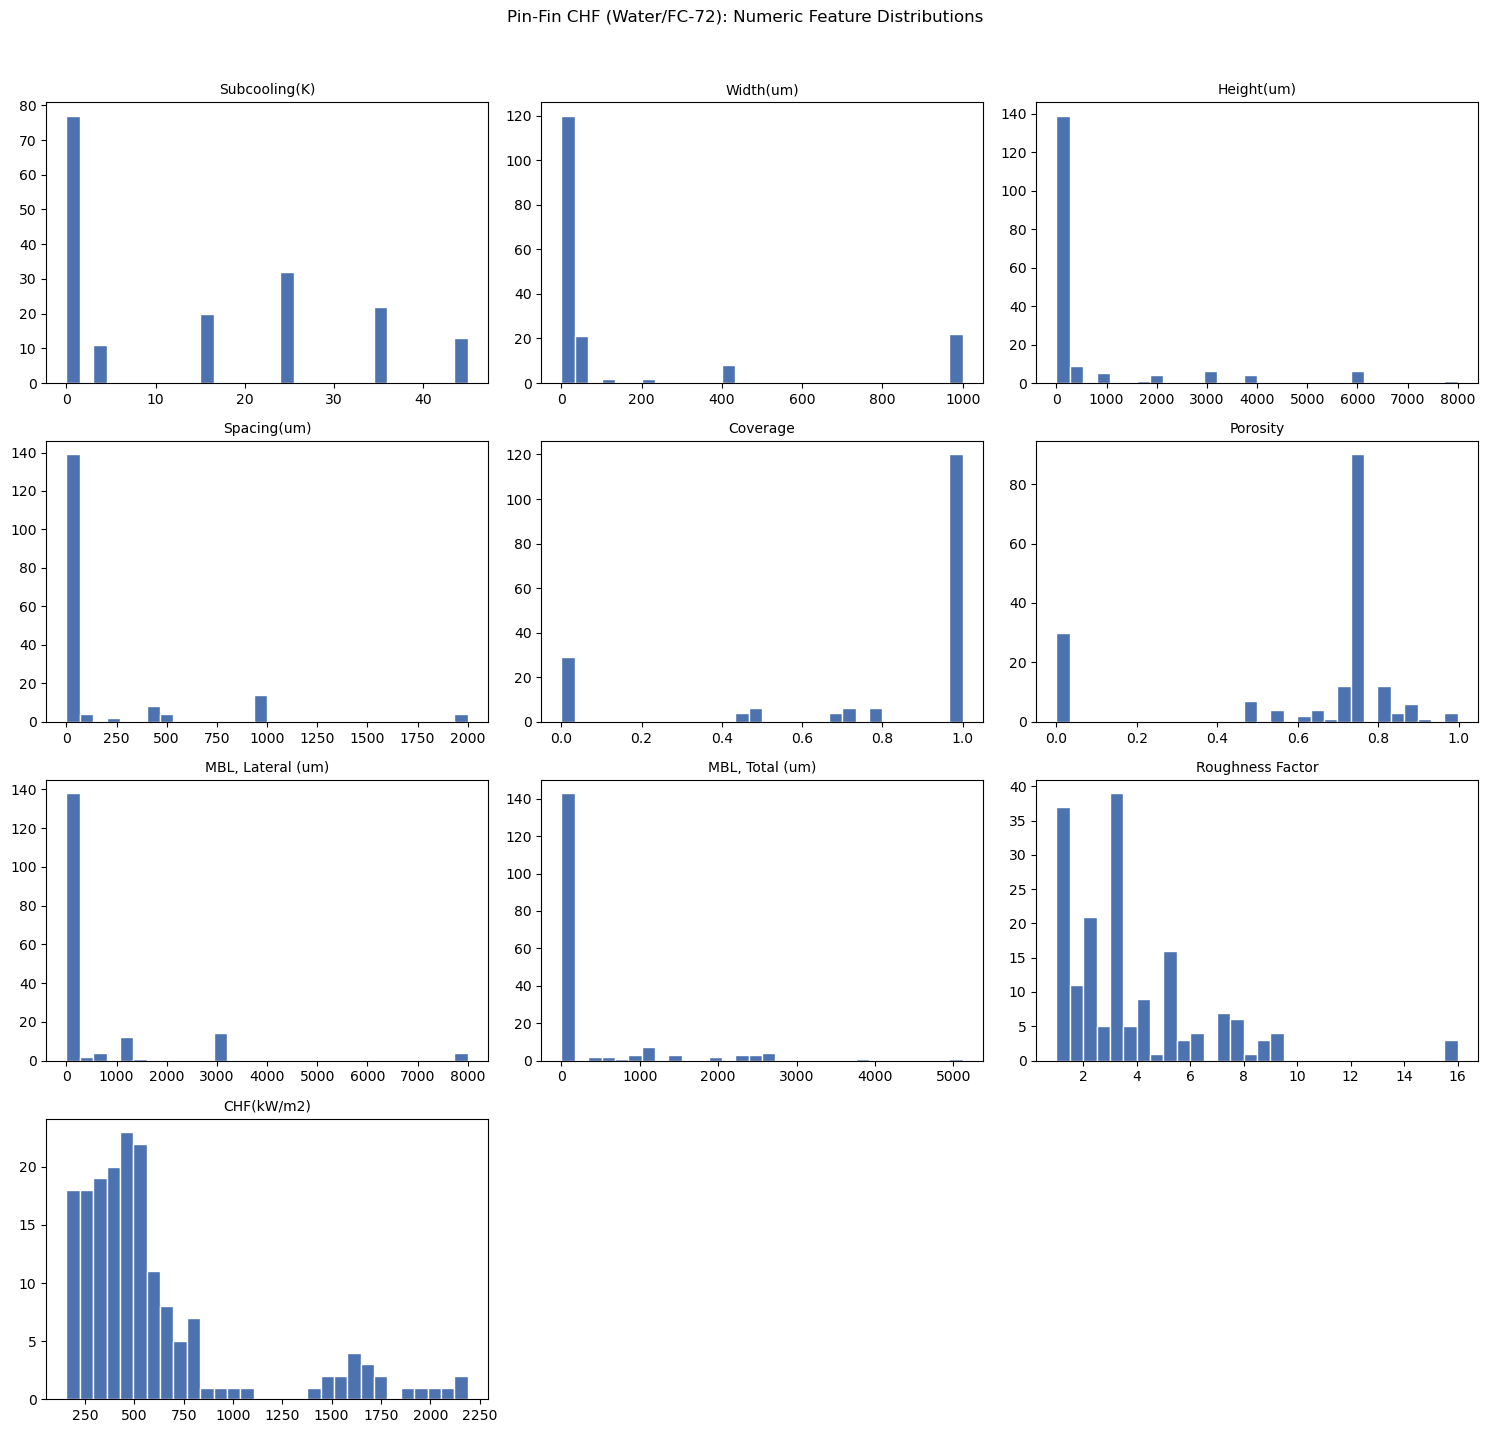

In [5]:
n = len(NUMERIC_COLS)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=10)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: Numeric Feature Distributions", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "histograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Outlier Scan (IQR, z-score)

In [6]:
iqr_rows = []
for col in NUMERIC_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    iqr_rows.append({
        "column": col, "q1": q1, "q3": q3, "iqr": iqr,
        "lower_fence": lo, "upper_fence": hi,
        "n_outliers": n_out, "pct_outliers": 100 * n_out / len(s) if len(s) else np.nan,
    })
iqr_table = pd.DataFrame(iqr_rows).set_index("column")
iqr_table.to_csv(OUT_DIR / "iqr_outlier_summary.csv")
iqr_table

,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers
column,,,,,,,
Subcooling(K),0.000,25.0000,25.0000,-37.50000,62.50000,0,0.000000
Width(um),10.000,50.0000,40.0000,-50.00000,110.00000,34,19.428571
Height(um),18.500,200.0000,181.5000,-253.75000,472.25000,31,17.714286
Spacing(um),10.000,50.0000,40.0000,-50.00000,110.00000,32,18.285714
Coverage,0.700,1.0000,0.3000,0.25000,1.45000,29,16.571429
Porosity,0.636,0.7500,0.1140,0.46500,0.92100,33,18.857143
"MBL, Lateral (um)",28.457,150.0000,121.5430,-153.85750,332.31450,35,20.000000
"MBL, Total (um)",22.883,90.3675,67.4845,-78.34375,191.59425,32,18.285714
Roughness Factor,1.887,5.0000,3.1130,-2.78250,9.66950,3,1.714286


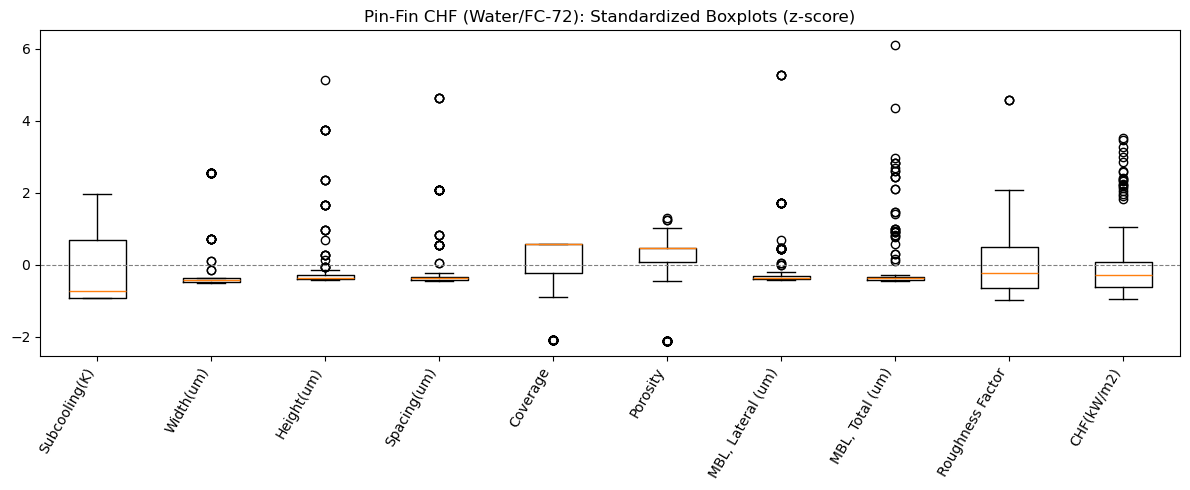

In [7]:
z = df[NUMERIC_COLS].apply(lambda s: (s - s.mean()) / s.std())
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(NUMERIC_COLS)), 5))
ax.boxplot([z[c].dropna() for c in NUMERIC_COLS])
ax.set_xticklabels(NUMERIC_COLS, rotation=60, ha="right")
ax.set_title(f"{SLUG_TITLE}: Standardized Boxplots (z-score)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
fig.tight_layout()
fig.savefig(FIG_DIR / "boxplots_standardized.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlation Structure

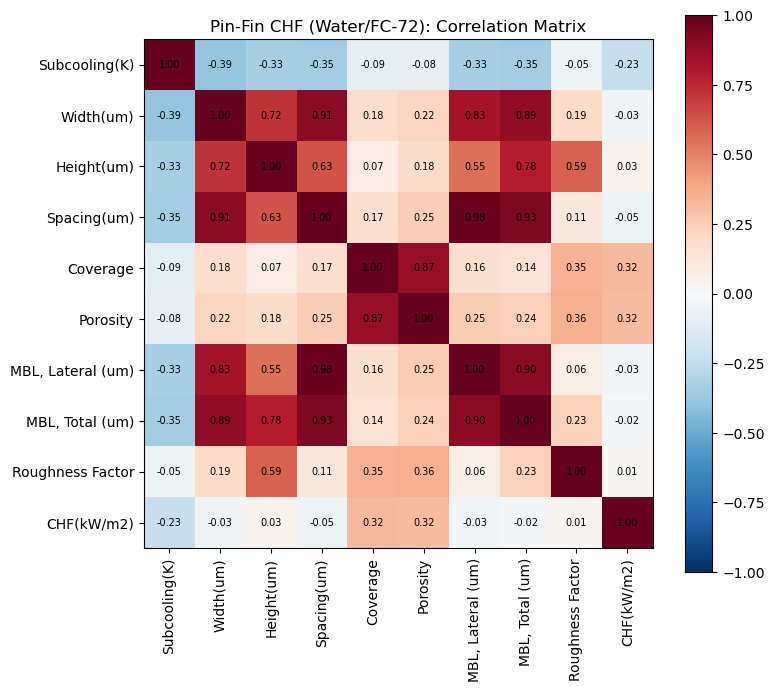

In [8]:
corr = df[NUMERIC_COLS].corr()
corr.to_csv(OUT_DIR / "correlation_matrix.csv")
fig, ax = plt.subplots(figsize=(0.6 * len(NUMERIC_COLS) + 2, 0.6 * len(NUMERIC_COLS) + 2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(NUMERIC_COLS)))
ax.set_xticklabels(NUMERIC_COLS, rotation=90)
ax.set_yticks(range(len(NUMERIC_COLS)))
ax.set_yticklabels(NUMERIC_COLS)
for i in range(len(NUMERIC_COLS)):
    for j in range(len(NUMERIC_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title(f"{SLUG_TITLE}: Correlation Matrix")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Target vs. Features

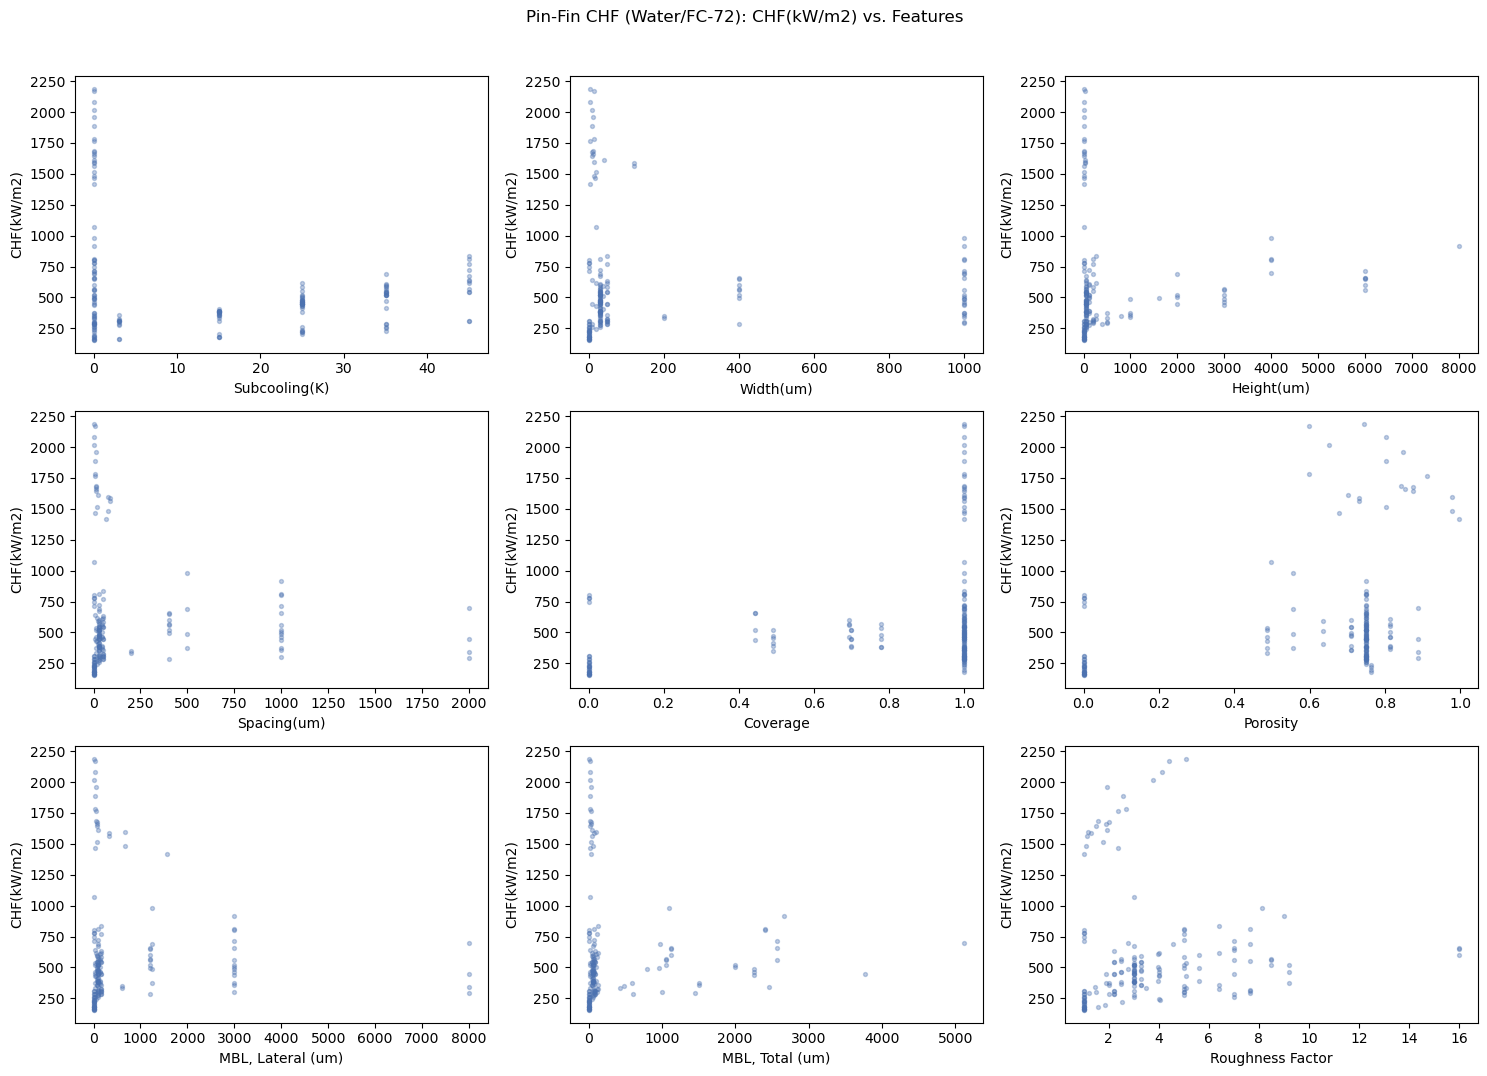

In [9]:
feature_cols = [c for c in NUMERIC_COLS if c != TARGET_COL]
n = len(feature_cols)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, feature_cols):
    ax.scatter(df[col], df[TARGET_COL], s=8, alpha=0.35, color="#4C72B0")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: {TARGET_COL} vs. Features", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "target_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Target by Category

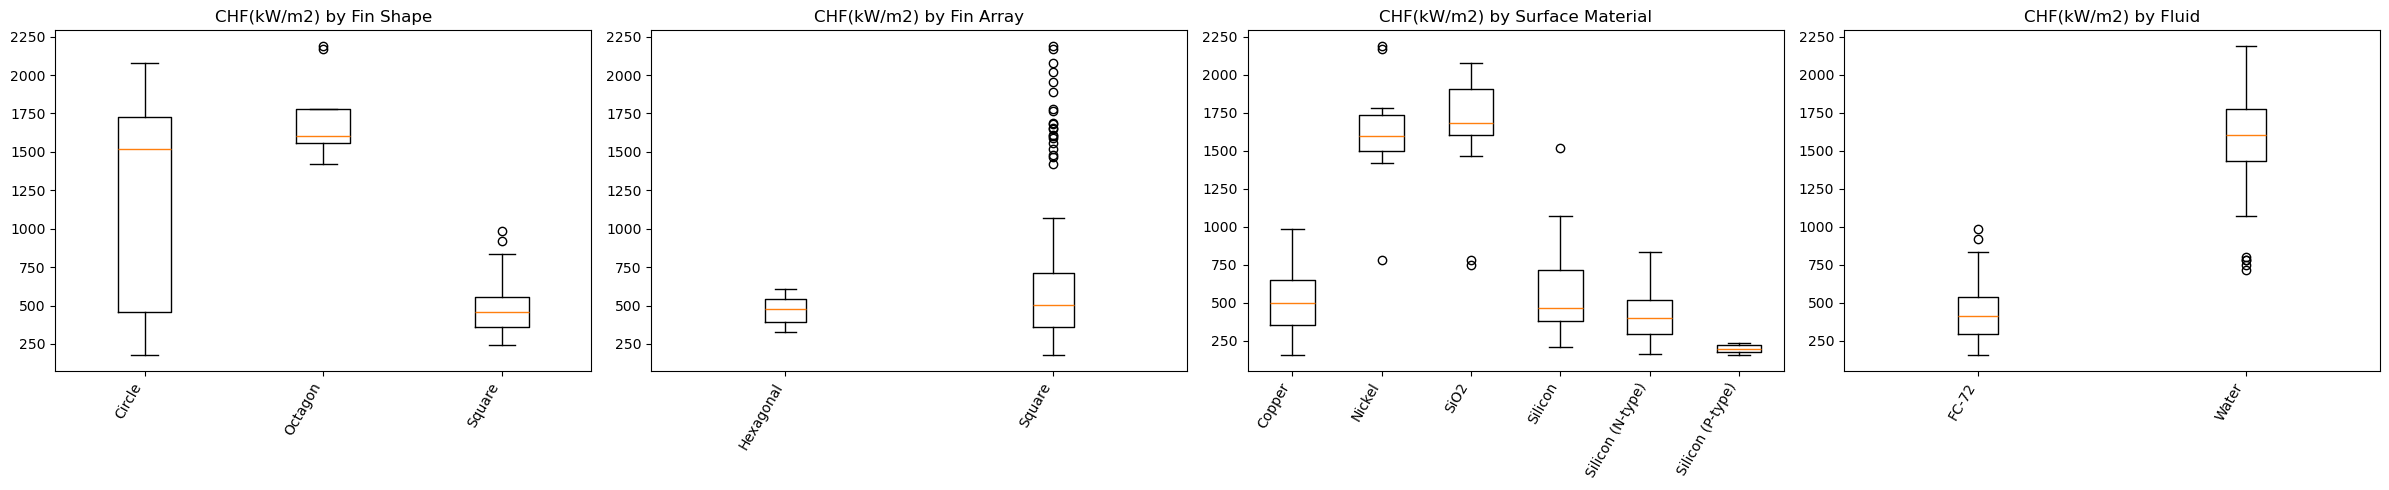

In [10]:
cat_cols_plot = [c for c in CATEGORICAL_COLS
                 if 2 <= df[c].nunique(dropna=True) <= 15]
if cat_cols_plot:
    fig, axes = plt.subplots(1, len(cat_cols_plot), figsize=(6 * len(cat_cols_plot), 5), squeeze=False)
    axes = axes[0]
    for ax, col in zip(axes, cat_cols_plot):
        groups = [g[TARGET_COL].dropna().values for _, g in df.groupby(col)]
        labels = [str(k) for k, _ in df.groupby(col)]
        ax.boxplot(groups)
        ax.set_xticklabels(labels, rotation=60, ha="right")
        ax.set_title(f"{TARGET_COL} by {col}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "target_by_category.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No low-cardinality categorical columns (2-15 unique values) available for grouped comparison.")


## 10. Takeaways

- The first row (`Fin Shape`/`Fin Array` = NaN, all geometry columns = 0) is a
  plain/unfinned reference surface — keep it as the baseline case, but be aware
  it will show up as an outlier / missing-category row in the checks above.
- `CHF(kW/m2)` is the modeling target; geometry columns (`Width`, `Height`,
  `Spacing`, `Coverage`, `Porosity`, the two `MBL` columns, `Roughness Factor`)
  are the engineered-surface features. `Subcooling(K)` is 0 for most rows in
  this extract (saturated pool boiling) — check the histogram above before
  using it as a continuous predictor.
- `Source` is a free-text citation column (mostly missing after the first row
  per source) — useful for provenance, not for modeling.
